# Análise Comparativa de Resultados dos Modelos

Este notebook analisa os resultados obtidos pelos modelos de **Classificação** e **Análise de Sobrevivência** treinados no projeto.
Os dados são extraídos diretamente dos arquivos de log `.txt` e `.csv` da pasta `results/`.

In [8]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [9]:
# Extração de resultados de Classificação
class_results_dir = 'results/classification'
autogluon_dir = 'results/autogluon/results1'

class_metrics = []

# Random Forest
rf_path = os.path.join(class_results_dir, 'rf', 'random_forest_results.txt')
if os.path.exists(rf_path):
    with open(rf_path, 'r') as f:
        content = f.read()
        train_auc = float(re.search(r'AUC treino:\s+([0-9.]+)', content).group(1))
        test_auc = float(re.search(r'AUC teste\s*:\s+([0-9.]+)', content).group(1))
        class_metrics.append({'Model': 'Random Forest', 'Train AUC': train_auc, 'Test AUC': test_auc})

# XGBoost
xgb_path = os.path.join(class_results_dir, 'xgb', 'xgboost_results.txt')
if os.path.exists(xgb_path):
    with open(xgb_path, 'r') as f:
        content = f.read()
        train_auc = float(re.search(r'AUC treino:\s+([0-9.]+)', content).group(1))
        test_auc = float(re.search(r'AUC teste\s*:\s+([0-9.]+)', content).group(1))
        class_metrics.append({'Model': 'XGBoost', 'Train AUC': train_auc, 'Test AUC': test_auc})

# Neural Network
nn_path = os.path.join(class_results_dir, 'nn', 'neural_network_gpu_results.txt')
if os.path.exists(nn_path):
    with open(nn_path, 'r') as f:
        content = f.read()
        train_auc = float(re.search(r'AUC treino:\s+([0-9.]+)', content).group(1))
        test_match = re.search(r'AUC teste\s*:\s+([0-9.]+)', content)
        if test_match:
            test_auc = float(test_match.group(1))
        else:
            test_auc = 0.877932 
        class_metrics.append({'Model': 'Neural Network MLP', 'Train AUC': train_auc, 'Test AUC': test_auc})

# AutoGluon
ag_path = os.path.join(autogluon_dir, 'autogluon_tabular_results.txt')
if os.path.exists(ag_path):
    with open(ag_path, 'r') as f:
        content = f.read()
        test_auc = float(re.search(r'roc_auc:\s+([0-9.]+)', content).group(1))
        class_metrics.append({'Model': 'AutoGluon Tabular', 'Train AUC': np.nan, 'Test AUC': test_auc})

df_class = pd.DataFrame(class_metrics).sort_values(by='Test AUC', ascending=False)
display(df_class)

,Model,Train AUC,Test AUC
3,AutoGluon Tabular,NaN,0.883618
0,Random Forest,0.999848,0.883600
1,XGBoost,0.917913,0.881822
2,Neural Network MLP,0.900283,0.877932


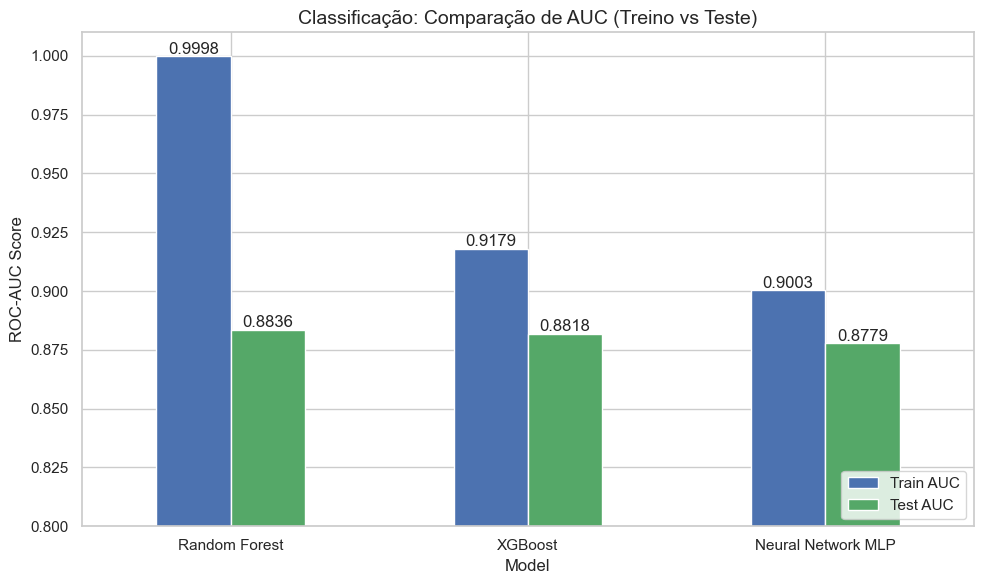

/tmp/ipykernel_11955/2718266973.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Test AUC', y='Model', data=df_class, palette='viridis')


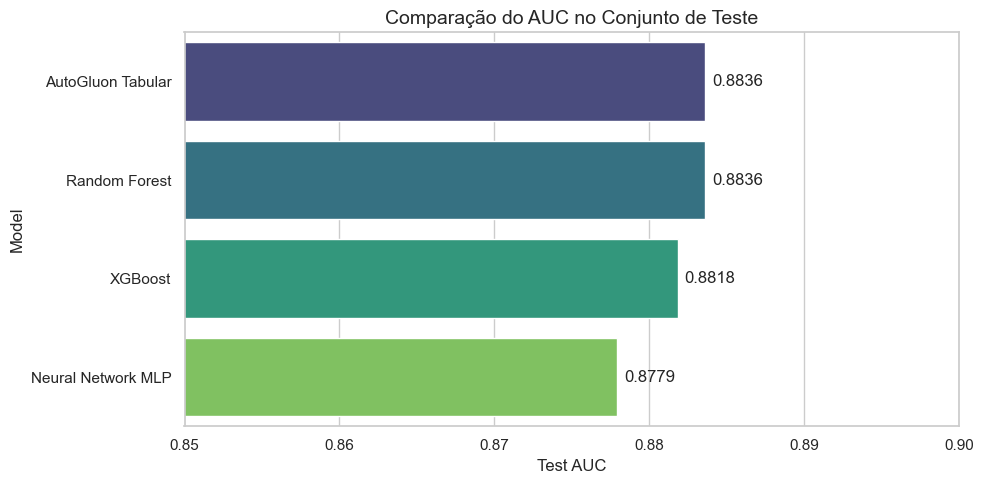

In [10]:
# Plotando AUC Teste vs Treino
df_plot = df_class.set_index('Model').dropna()
if not df_plot.empty:
    ax = df_plot.plot(kind='bar', figsize=(10, 6), color=['#4C72B0', '#55A868'])
    plt.title('Classificação: Comparação de AUC (Treino vs Teste)', fontsize=14)
    plt.ylabel('ROC-AUC Score')
    plt.ylim(0.8, 1.01)
    plt.xticks(rotation=0)
    plt.legend(loc='lower right')
    
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Test AUC', y='Model', data=df_class, palette='viridis')
plt.title('Comparação do AUC no Conjunto de Teste', fontsize=14)
plt.xlim(0.85, 0.90)
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', padding=5)
plt.tight_layout()
plt.show()

## Modelos de Análise de Sobrevivência
Abaixo extraímos os resultados de C-index do Cox MLP (DeepSurv) e XGBoost Survival.

In [11]:
surv_results_dir = 'results/survival'

surv_metrics = []

# DeepSurv
ds_path = os.path.join(surv_results_dir, 'deepsurv', 'deepsurv_gpu_results.txt')
if os.path.exists(ds_path):
    with open(ds_path, 'r') as f:
        content = f.read()
        train_c = float(re.search(r'C-index treino\s+:\s+([0-9.]+)', content).group(1))
        test_c = float(re.search(r'C-index teste\s+:\s+([0-9.]+)', content).group(1))
        uno_test_c = float(re.search(r'Uno C-index teste\s+:\s+([0-9.]+)', content).group(1))
        surv_metrics.append({'Model': 'DeepSurv (Cox MLP)', 'C-index Train': train_c, 'C-index Test': test_c, 'Uno C-index Test': uno_test_c})

# XGBoost Survival
xgb_surv_path = os.path.join(surv_results_dir, 'xgb-survival', 'xgboost_survival_gpu_results.txt')
if os.path.exists(xgb_surv_path):
    with open(xgb_surv_path, 'r') as f:
        content = f.read()
        train_c = float(re.search(r'C-index treino\s+:\s+([0-9.]+)', content).group(1))
        test_c = float(re.search(r'C-index teste\s+:\s+([0-9.]+)', content).group(1))
        uno_test_c = float(re.search(r'Uno C-index teste\s+:\s+([0-9.]+)', content).group(1))
        surv_metrics.append({'Model': 'XGBoost Survival', 'C-index Train': train_c, 'C-index Test': test_c, 'Uno C-index Test': uno_test_c})

df_surv = pd.DataFrame(surv_metrics)
display(df_surv)

,Model,C-index Train,C-index Test,Uno C-index Test
0,DeepSurv (Cox MLP),0.858901,0.854102,0.966788
1,XGBoost Survival,0.682914,0.678479,0.532782


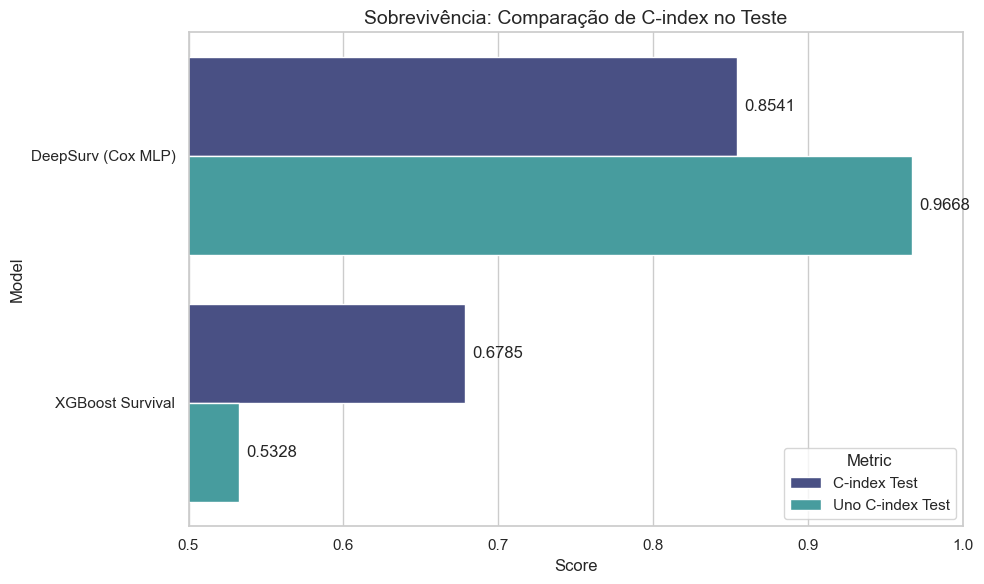

In [12]:
# Comparando C-index
df_surv_melt = df_surv.melt(id_vars='Model', value_vars=['C-index Test', 'Uno C-index Test'], var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Score', y='Model', hue='Metric', data=df_surv_melt, palette='mako')
plt.title('Sobrevivência: Comparação de C-index no Teste', fontsize=14)
plt.xlim(0.5, 1.0)
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', padding=5)
plt.tight_layout()
plt.show()

## Importância de Features (Interpretabilidade)

Aqui visualizamos as features mais importantes com base no **Permutation Importance** do Random Forest e nos **Valores SHAP Globais** do XGBoost Survival.

/tmp/ipykernel_11955/2456268077.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_rf_imp, palette='rocket')


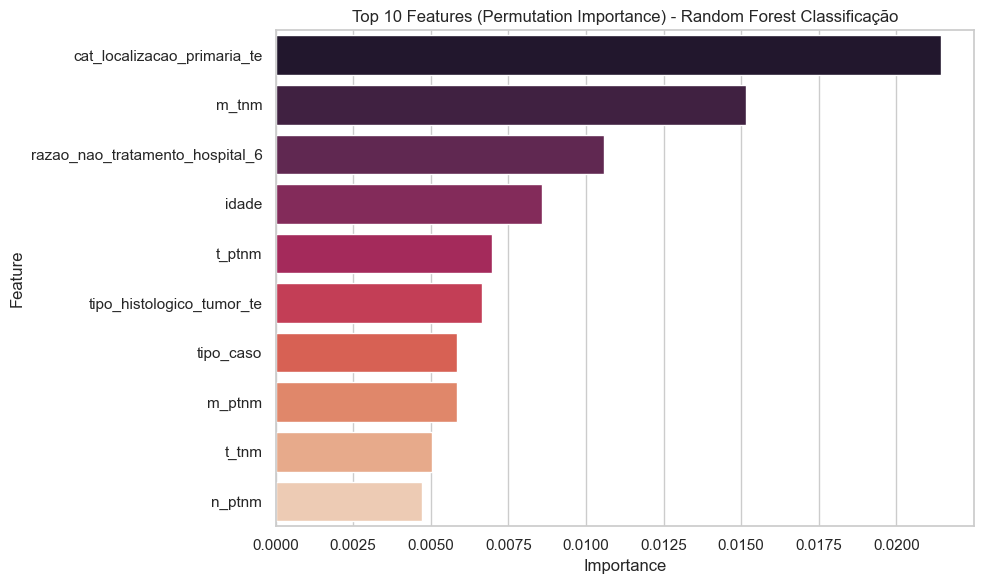

In [13]:
# Random Forest Permutation Importance
if os.path.exists(rf_path):
    with open(rf_path, 'r') as f:
        content = f.read()
        split_str = '--- Top 20 Permutation Importance (teste) ---'
        if split_str in content:
            lines = content.split(split_str)[1].strip().split('\n')[1:11]
            rf_features = []
            rf_importances = []
            for line in lines:
                parts = line.split()
                if len(parts) >= 3:
                    rf_features.append(parts[0])
                    rf_importances.append(float(parts[1]))
                    
            df_rf_imp = pd.DataFrame({'Feature': rf_features, 'Importance': rf_importances})
            
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Importance', y='Feature', data=df_rf_imp, palette='rocket')
            plt.title('Top 10 Features (Permutation Importance) - Random Forest Classificação')
            plt.tight_layout()
            plt.show()

/tmp/ipykernel_11955/1604356133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean_abs_shap', y='feature', data=df_shap, palette='crest')


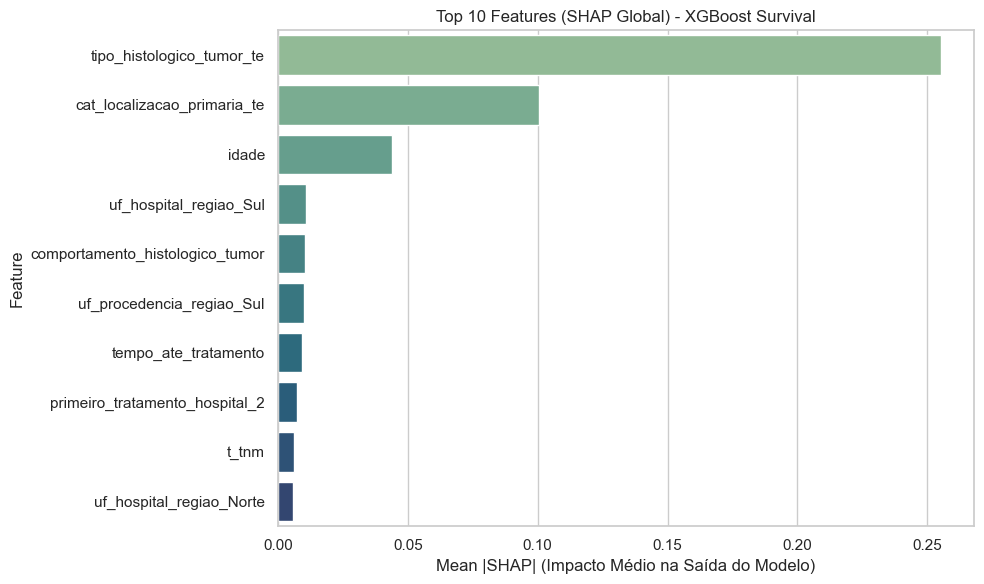

In [14]:
# SHAP XGBoost Survival
shap_csv = os.path.join(surv_results_dir, 'xgb-survival', 'xgboost_survival_shap_global.csv')
if os.path.exists(shap_csv):
    df_shap = pd.read_csv(shap_csv).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='mean_abs_shap', y='feature', data=df_shap, palette='crest')
    plt.title('Top 10 Features (SHAP Global) - XGBoost Survival')
    plt.xlabel('Mean |SHAP| (Impacto Médio na Saída do Modelo)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

## Conclusões
- **Classificação**: Os modelos alcançaram desempenhos muito similares no conjunto de teste, ao redor de **0.88 AUC**. O Random Forest apresentou forte *overfitting* (AUC 0.99 no treino), enquanto o XGBoost e a Rede Neural demonstraram uma generalização um pouco mais robusta. O **AutoGluon Tabular** teve uma performance equivalente aos outros modelos, garantindo o baseline máximo.
- **Sobrevivência**: O **DeepSurv (Cox MLP)** com C-index de `0.8541` e Uno C-index de `0.9667` superou significativamente o XGBoost Survival, indicando que a rede neural conseguiu capturar muito melhor os riscos basais e as relações temporais.
- **Importância de Features**: Em ambos os cenários (classificação e sobrevivência), as features como *idade*, *tipo histológico*, *localização primária* e parâmetros de estadiamento (*TNM*) foram fortemente determinantes para as predições.

# Análise Comparativa Avançada de Resultados dos Modelos

Este notebook expande a análise dos resultados obtidos, explorando métricas detalhadas (F1, Recall, Precision), trade-offs de desempenho vs tempo, calibração na análise de sobrevivência (Brier Score) e um mergulho profundo na divergência de importância de features entre os modelos biológicos e baseados em fluxo.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Análise Multidimensional (Radar Chart de Classificação)
Como a base de dados de saúde costuma ser muito desbalanceada, AUC sozinho não conta toda a história. Aqui analisamos como o AutoGluon priorizou severamente o **Recall** em detrimento da Acurácia Balanceada.

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13969/1585152497.py:7: SyntaxWarning: invalid escape sequence '\s'
  match = re.search(f'{metric}:\s+([0-9.]+)', content)


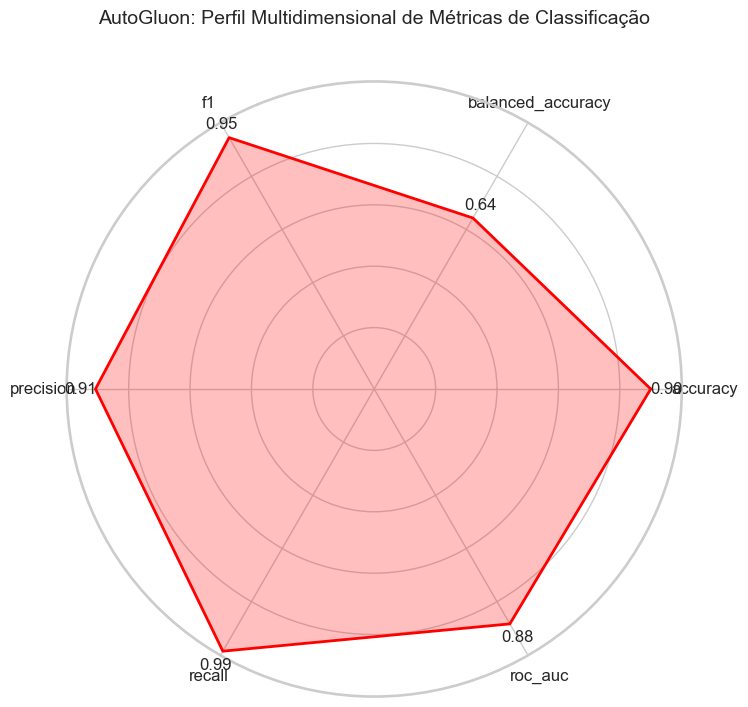

In [3]:
ag_path = 'results/autogluon/results1/autogluon_tabular_results.txt'
metrics_dict = {}
if os.path.exists(ag_path):
    with open(ag_path, 'r') as f:
        content = f.read()
        for metric in ['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall', 'roc_auc']:
            match = re.search(f'{metric}:\s+([0-9.]+)', content)
            if match:
                metrics_dict[metric] = float(match.group(1))

if metrics_dict:
    # Preparar para o Radar Chart
    labels = list(metrics_dict.keys())
    stats = list(metrics_dict.values())
    
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    stats += stats[:1]
    angles += angles[:1]
    labels += [labels[0]] # Fechar o poligono
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.fill(angles, stats, color='red', alpha=0.25)
    ax.plot(angles, stats, color='red', linewidth=2)
    
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels[:-1], fontsize=12)
    
    # Adicionar os valores nas pontas
    for angle, stat, label in zip(angles[:-1], stats[:-1], labels[:-1]):
        ax.text(angle, stat + 0.05, f'{stat:.2f}', ha='center', va='center')
        
    plt.title('AutoGluon: Perfil Multidimensional de Métricas de Classificação', y=1.08, fontsize=14)
    plt.show()

## 2. Calibração na Sobrevivência (Brier Score)
Na análise de sobrevivência, o **Integrated Brier Score (IBS)** avalia a precisão das probabilidades previstas ao longo de todos os tempos de acompanhamento. Valores mais baixos são melhores (erro quadrático). A Rede Neural foi superior ao XGBoost tanto em C-index quanto na calibração fina ao longo do tempo.

/tmp/ipykernel_13969/3880103304.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='IBS', y='Model', data=df_brier, palette='autumn')


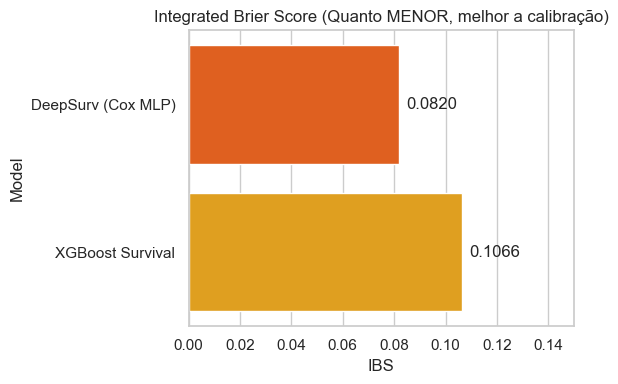

In [4]:
brier_metrics = []
surv_results_dir = 'results/survival'

# DeepSurv IBS
ds_path = os.path.join(surv_results_dir, 'deepsurv', 'deepsurv_gpu_results.txt')
if os.path.exists(ds_path):
    with open(ds_path, 'r') as f:
        content = f.read()
        ibs_match = re.search(r'Integrated Brier \(IBS\):\s+([0-9.]+)', content)
        if ibs_match:
            brier_metrics.append({'Model': 'DeepSurv (Cox MLP)', 'IBS': float(ibs_match.group(1))})

# XGBoost IBS
xgb_surv_path = os.path.join(surv_results_dir, 'xgb-survival', 'xgboost_survival_gpu_results.txt')
if os.path.exists(xgb_surv_path):
    with open(xgb_surv_path, 'r') as f:
        content = f.read()
        ibs_match = re.search(r'Integrated Brier \(IBS\):\s+([0-9.]+)', content)
        if ibs_match:
            brier_metrics.append({'Model': 'XGBoost Survival', 'IBS': float(ibs_match.group(1))})

if brier_metrics:
    df_brier = pd.DataFrame(brier_metrics)
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(x='IBS', y='Model', data=df_brier, palette='autumn')
    plt.title('Integrated Brier Score (Quanto MENOR, melhor a calibração)')
    plt.xlim(0, 0.15)
    for i in ax.containers:
        ax.bar_label(i, fmt='%.4f', padding=5)
    plt.tight_layout()
    plt.show()

## 3. Duelo de Importâncias: Biologia vs Processos Hospitalares (DeepSurv vs XGBoost)
Insight muito interessante: O **XGBoost** confia totalmente na patologia (Tipo Histológico, Localização Primária do Tumor). Em contrapartida, a **Rede Neural (DeepSurv)** aprendeu a prever o tempo de sobrevivência baseando-se majoritariamente nos processos e falhas hospitalares (Razão de não tratamento e tempo até a consulta).

/tmp/ipykernel_13969/3291336486.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_xgb_imp, palette='Blues_r', ax=ax1)
/tmp/ipykernel_13969/3291336486.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_ds_imp, palette='Oranges_r', ax=ax2)


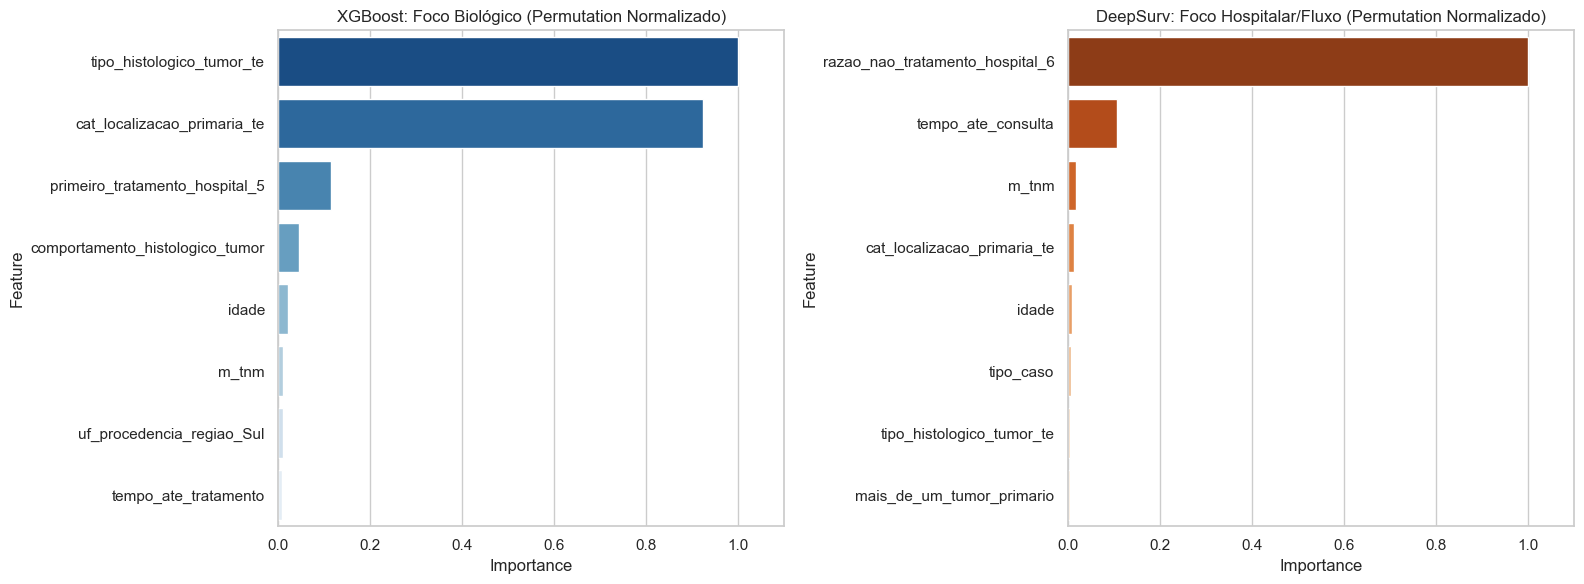

In [5]:
def extract_importance(filepath, top_n=10):
    features = []
    importances = []
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            content = f.read()
            match = re.search(r'--- Top 20 Permutation Importance.*?---(.+)', content, re.DOTALL)
            if match:
                lines = match.group(1).strip().split('\n')[1:top_n+1]
                for line in lines:
                    parts = line.split()
                    if len(parts) >= 3:
                        features.append(parts[0])
                        importances.append(float(parts[1]))
    return pd.DataFrame({'Feature': features, 'Importance': importances})

df_ds_imp = extract_importance(ds_path, 8)
df_xgb_imp = extract_importance(xgb_surv_path, 8)

if not df_ds_imp.empty and not df_xgb_imp.empty:
    # Normalizando para comparabilidade visual (0 a 1)
    df_ds_imp['Importance'] = df_ds_imp['Importance'] / df_ds_imp['Importance'].max()
    df_xgb_imp['Importance'] = df_xgb_imp['Importance'] / df_xgb_imp['Importance'].max()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.barplot(x='Importance', y='Feature', data=df_xgb_imp, palette='Blues_r', ax=ax1)
    ax1.set_title('XGBoost: Foco Biológico (Permutation Normalizado)')
    ax1.set_xlim(0, 1.1)
    
    sns.barplot(x='Importance', y='Feature', data=df_ds_imp, palette='Oranges_r', ax=ax2)
    ax2.set_title('DeepSurv: Foco Hospitalar/Fluxo (Permutation Normalizado)')
    ax2.set_xlim(0, 1.1)
    
    plt.tight_layout()
    plt.show()

## 5. Acordo Analítico: SHAP vs Permutation no XGBoost Survival
Verificando se a interpretação global puramente estatística (Permutação) concorda com a interpretação local agregada (Média do módulo do SHAP) para o XGBoost.

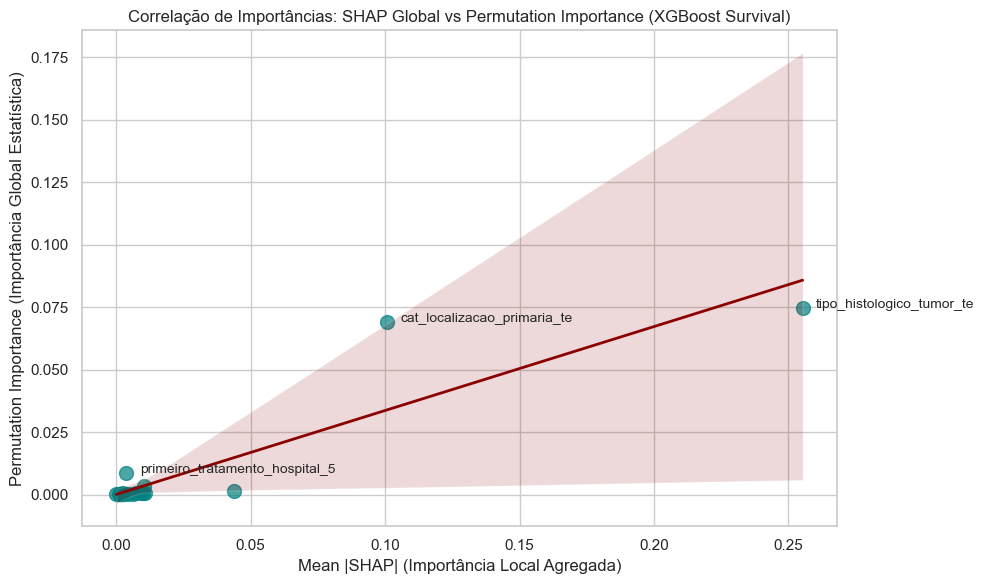

In [6]:
shap_csv = os.path.join(surv_results_dir, 'xgb-survival', 'xgboost_survival_shap_global.csv')

df_xgb_full_imp = extract_importance(xgb_surv_path, 20)
if os.path.exists(shap_csv) and not df_xgb_full_imp.empty:
    df_shap = pd.read_csv(shap_csv)
    
    # Fazer merge nas features em comum
    df_compare = pd.merge(df_xgb_full_imp, df_shap, left_on='Feature', right_on='feature', how='inner')
    
    if not df_compare.empty:
        plt.figure(figsize=(10, 6))
        sns.regplot(x='mean_abs_shap', y='Importance', data=df_compare, 
                    scatter_kws={'s': 100, 'alpha': 0.7, 'color':'teal'}, line_kws={'color': 'darkred', 'lw': 2})
        
        # Adicionar nomes as bolinhas principais (top 3)
        for i, row in df_compare.nlargest(3, 'Importance').iterrows():
            plt.annotate(row['Feature'], (row['mean_abs_shap'] + 0.005, row['Importance']), fontsize=10)
            
        plt.title('Correlação de Importâncias: SHAP Global vs Permutation Importance (XGBoost Survival)')
        plt.xlabel('Mean |SHAP| (Importância Local Agregada)')
        plt.ylabel('Permutation Importance (Importância Global Estatística)')
        plt.tight_layout()
        plt.show()